# Lesson 10: Modern Machine Learning Techniques

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
**Lecture 10 of the extended econometrics sequence**

This lecture introduces modern machine learning as a set of tools for prediction, classification, pattern recognition, dimensionality reduction, and nonlinear approximation.

Earlier lectures emphasized probability, regression, causal inference, asset pricing, and panel-data identification. This lecture shifts the objective from causal estimation to **out-of-sample prediction**.

## Learning goals

By the end of this lecture, you should be able to:

1. Explain the difference between prediction and causal inference.
2. Split data into training and testing samples.
3. Evaluate out-of-sample fit using appropriate metrics.
4. Understand bias, variance, overfitting, and regularization.
5. Estimate and compare linear regression, Ridge, LASSO, and Elastic Net.
6. Use logistic regression for classification.
7. Estimate decision trees, support vector machines, k-nearest neighbors, and naive Bayes classifiers.
8. Understand clustering with $k$-means.
9. Use principal components analysis for dimensionality reduction.
10. Understand the basic logic of neural networks, gradient descent, and backpropagation.

Machine learning is not magic. It is disciplined function approximation.

In [1]:
# Core imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification, make_blobs, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    silhouette_score
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

np.random.seed(42)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

## 1. Prediction versus Causal Inference

A causal question asks:

> What would happen to $Y$ if we changed $X$?

A prediction question asks:

> Given the information available, what value of $Y$ should we forecast?

These are related but different tasks. A variable can be useful for prediction even if it is not causal. Conversely, a causal variable may be hard to use predictively if it is measured with noise or observed infrequently.

The standard machine-learning setup is

$$
Y_i = f(X_i) + \varepsilon_i,
$$

where the goal is to learn an approximation

$$
\hat{f}(X)
$$

that predicts new observations well.

The central object is **out-of-sample error**:

$$
E_{new}\left[(Y_{new}-\hat{f}(X_{new}))^2\right].
$$

A model is judged not by how well it explains the data it has already seen, but by how well it predicts data it has not seen.

## 2. Training Data, Testing Data, and Out-of-Sample Fit

Machine learning usually divides the sample into:

- **Training data**: used to estimate the model.
- **Testing data**: held out and used to evaluate predictive performance.
- **Validation data** or **cross-validation folds**: used to choose tuning parameters.

For regression problems, common metrics are:

$$
MSE = \frac{1}{n}\sum_{i=1}^n (y_i-\hat{y}_i)^2,
$$

$$
RMSE = \sqrt{MSE},
$$

$$
MAE = \frac{1}{n}\sum_{i=1}^n |y_i-\hat{y}_i|,
$$

and

$$
R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}.
$$

For classification problems, common metrics include accuracy, precision, recall, F1 score, and the area under the ROC curve.

In [2]:
# Simulate a regression dataset

X_reg, y_reg = make_regression(
    n_samples=1000,
    n_features=20,
    n_informative=8,
    noise=25,
    random_state=42
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

print('Training sample size:', X_train_reg.shape)
print('Testing sample size:', X_test_reg.shape)

Training sample size: (750, 20)
Testing sample size: (250, 20)


In [5]:
def regression_report(model, X_train, X_test, y_train, y_test, name='Model'):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return pd.Series({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred)
    })

lin_report = regression_report(LinearRegression(), X_train_reg, X_test_reg, y_train_reg, y_test_reg, 'OLS')
pd.DataFrame([lin_report])

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,OLS,25.467878,24.570488,20.446648,19.289531,0.982387,0.981275


## 3. Bias, Variance, and Overfitting

Prediction error can be decomposed conceptually into three parts:

$$
E[(Y-\hat{f}(X))^2]
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Error}.
$$

- **Bias** is error from using a model that is too simple.
- **Variance** is error from using a model that is too sensitive to the training sample.
- **Irreducible error** is noise that cannot be predicted from the available features.

A flexible model can fit the training sample very well but perform poorly out of sample. This is **overfitting**.

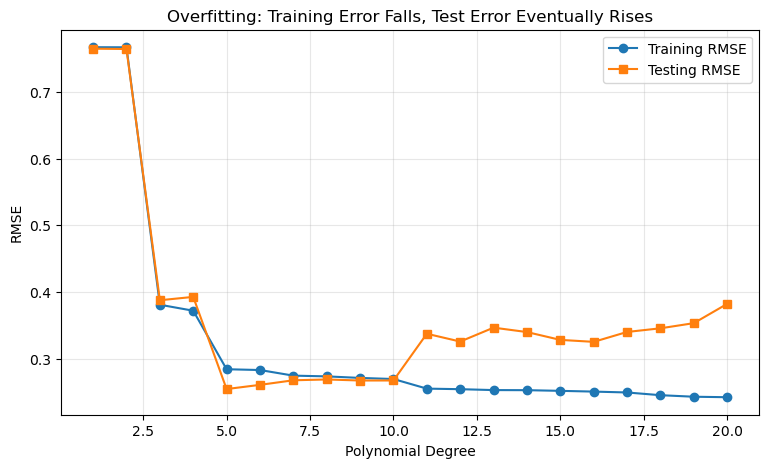

In [7]:
# Overfitting with polynomial regression

np.random.seed(42)
n = 120
x = np.linspace(-3, 3, n)
y_true = np.sin(1.5 * x)
y = y_true + np.random.normal(0, 0.30, n)

X = x.reshape(-1, 1)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X, y, test_size=0.35, random_state=42
)

degrees = list(range(1, 21))
train_rmse = []
test_rmse = []

for d in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])
    model.fit(X_train_poly, y_train_poly)
    train_rmse.append(np.sqrt(mean_squared_error(y_train_poly, model.predict(X_train_poly))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test_poly, model.predict(X_test_poly))))

plt.figure(figsize=(9, 5))
plt.plot(degrees, train_rmse, marker='o', label='Training RMSE')
plt.plot(degrees, test_rmse, marker='s', label='Testing RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Overfitting: Training Error Falls, Test Error Eventually Rises')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Cross-Validation

A single train/test split can be noisy. Cross-validation gives a more stable estimate of out-of-sample performance.

In $K$-fold cross-validation:

1. Split the data into $K$ folds.
2. Estimate the model on $K-1$ folds.
3. Test on the remaining fold.
4. Repeat until each fold has served as the test fold.
5. Average the test errors.

For a tuning parameter $\lambda$, choose the value that minimizes cross-validated prediction error:

$$
\hat{\lambda}
=
\arg\min_{\lambda}
\frac{1}{K}
\sum_{k=1}^K
Loss_k(\lambda).
$$

In [9]:
# Cross-validation example for Ridge regression

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': np.logspace(-3, 4, 30)
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5
)

ridge_grid.fit(X_train_reg, y_train_reg)

print('Best Ridge alpha:', ridge_grid.best_params_['ridge__alpha'])
print('Best cross-validated RMSE:', -ridge_grid.best_score_)

Best Ridge alpha: 0.2592943797404667
Best cross-validated RMSE: 26.234360705100745


## 5. Linear Regression as a Prediction Model

The linear prediction model is

$$
\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1x_{i1} + \cdots + \hat{\beta}_kx_{ik}.
$$

Ordinary least squares chooses coefficients to minimize the sum of squared residuals:

$$
\min_{\beta}
\sum_{i=1}^n (y_i - x_i'\beta)^2.
$$

In matrix form, the solution is

$$
\hat{\beta}_{OLS} = (X'X)^{-1}X'Y,
$$

when $X'X$ is invertible.

In [11]:
models_reg = []
models_reg.append(regression_report(
    LinearRegression(),
    X_train_reg, X_test_reg, y_train_reg, y_test_reg,
    'OLS'
))

models_reg.append(regression_report(
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=ridge_grid.best_params_['ridge__alpha']))]),
    X_train_reg, X_test_reg, y_train_reg, y_test_reg,
    'Ridge'
))

pd.DataFrame(models_reg)

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,OLS,25.467878,24.570488,20.446648,19.289531,0.982387,0.981275
1,Ridge,25.467960,24.574705,20.446217,19.290256,0.982387,0.981268


## 6. Ridge Regression

Ridge regression penalizes large coefficients:

$$
\min_{\beta}
\sum_{i=1}^n (y_i - x_i'\beta)^2
+
\lambda \sum_{j=1}^k \beta_j^2.
$$

The parameter $\lambda \geq 0$ controls the strength of regularization.

- When $\lambda=0$, Ridge is OLS.
- As $\lambda$ increases, coefficients are shrunk toward zero.
- Ridge usually keeps all predictors in the model.
- Ridge is especially useful when predictors are highly correlated.

Ridge lowers variance by accepting some bias.

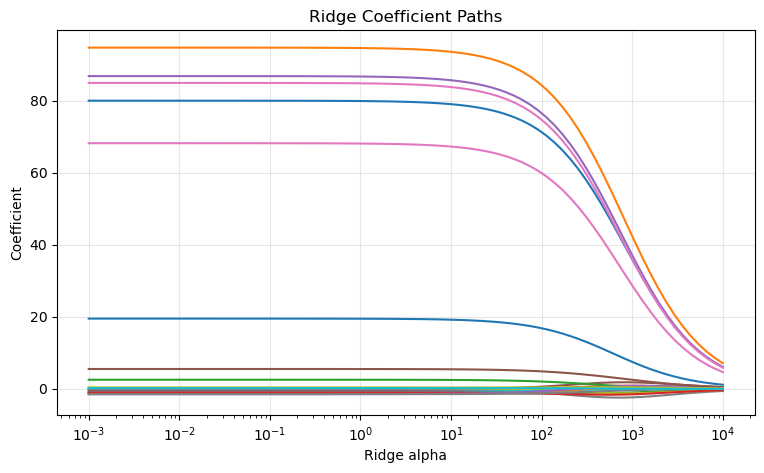

In [13]:
# Ridge coefficient paths

alphas = np.logspace(-3, 4, 80)
ridge_coefs = []

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_reg)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(9, 5))
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.xlabel('Ridge alpha')
plt.ylabel('Coefficient')
plt.title('Ridge Coefficient Paths')
plt.grid(True, alpha=0.3)
plt.show()

## 7. LASSO Regression

LASSO uses an absolute-value penalty:

$$
\min_{\beta}
\sum_{i=1}^n (y_i - x_i'\beta)^2
+
\lambda \sum_{j=1}^k |\beta_j|.
$$

Unlike Ridge, LASSO can set some coefficients exactly equal to zero. This makes LASSO useful for **variable selection**.

In [15]:
# LASSO cross-validation

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipeline,
    {'lasso__alpha': np.logspace(-3, 2, 40)},
    scoring='neg_root_mean_squared_error',
    cv=5
)

lasso_grid.fit(X_train_reg, y_train_reg)

print('Best LASSO alpha:', lasso_grid.best_params_['lasso__alpha'])
print('Best cross-validated RMSE:', -lasso_grid.best_score_)

models_reg.append(regression_report(
    Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=lasso_grid.best_params_['lasso__alpha'], max_iter=10000))]),
    X_train_reg, X_test_reg, y_train_reg, y_test_reg,
    'LASSO'
))

pd.DataFrame(models_reg)

Best LASSO alpha: 0.49238826317067363
Best cross-validated RMSE: 26.122929070586984


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,OLS,25.467878,24.570488,20.446648,19.289531,0.982387,0.981275
1,Ridge,25.467960,24.574705,20.446217,19.290256,0.982387,0.981268
2,LASSO,25.549414,24.450878,20.476054,19.219567,0.982274,0.981457


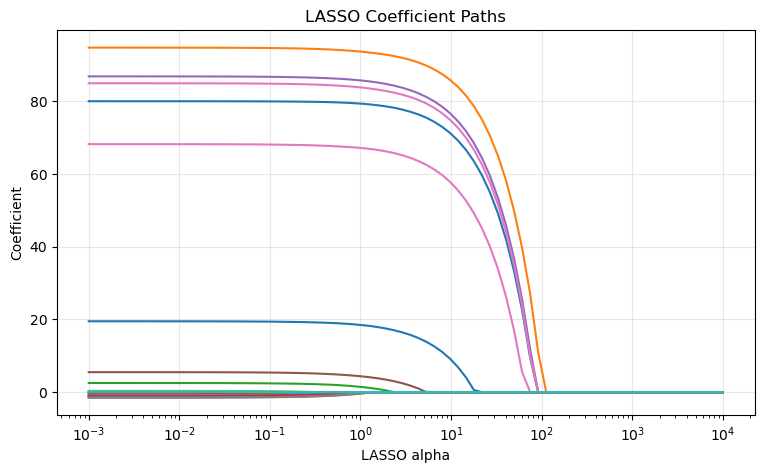

In [17]:
# LASSO coefficient paths

lasso_coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_reg)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(9, 5))
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.xlabel('LASSO alpha')
plt.ylabel('Coefficient')
plt.title('LASSO Coefficient Paths')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Elastic Net

Elastic Net combines Ridge and LASSO:

$$
\min_{\beta}
\sum_{i=1}^n (y_i - x_i'\beta)^2
+
\lambda
\left[
\alpha \sum_{j=1}^k |\beta_j|
+
\frac{1-\alpha}{2}\sum_{j=1}^k \beta_j^2
\right].
$$

Here:

- $\lambda$ controls total regularization strength.
- $\alpha$ controls the mixture of LASSO and Ridge.
- $\alpha=1$ gives LASSO.
- $\alpha=0$ gives Ridge.

Elastic Net is useful when predictors are correlated and variable selection is still desired.

In [19]:
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(max_iter=20000))
])

elastic_grid = GridSearchCV(
    elastic_pipeline,
    {
        'elastic__alpha': np.logspace(-3, 2, 20),
        'elastic__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    scoring='neg_root_mean_squared_error',
    cv=5
)

elastic_grid.fit(X_train_reg, y_train_reg)

print('Best Elastic Net parameters:', elastic_grid.best_params_)
print('Best cross-validated RMSE:', -elastic_grid.best_score_)

models_reg.append(regression_report(
    elastic_grid.best_estimator_,
    X_train_reg, X_test_reg, y_train_reg, y_test_reg,
    'Elastic Net'
))

pd.DataFrame(models_reg)

Best Elastic Net parameters: {'elastic__alpha': 0.02069138081114789, 'elastic__l1_ratio': 0.9}
Best cross-validated RMSE: 26.22849925565355


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,OLS,25.467878,24.570488,20.446648,19.289531,0.982387,0.981275
1,Ridge,25.467960,24.574705,20.446217,19.290256,0.982387,0.981268
2,LASSO,25.549414,24.450878,20.476054,19.219567,0.982274,0.981457
3,Elastic Net,25.471613,24.588682,20.445109,19.300697,0.982382,0.981247


## 9. Logistic Regression for Classification

For binary classification, the dependent variable is

$$
Y_i \in \{0,1\}.
$$

Logistic regression models the probability of class 1:

$$
P(Y_i=1\mid X_i)
=
\frac{1}{1+\exp(-X_i'\beta)}.
$$

Equivalently, the log-odds are linear:

$$
\log\left(\frac{P(Y_i=1\mid X_i)}{1-P(Y_i=1\mid X_i)}\right)
=
X_i'\beta.
$$

In [21]:
# Simulate classification data

X_cls, y_cls = make_classification(
    n_samples=1200,
    n_features=12,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.30, random_state=42, stratify=y_cls
)

print('Training sample:', X_train_cls.shape)
print('Testing sample:', X_test_cls.shape)

Training sample: (840, 12)
Testing sample: (360, 12)


In [23]:
def classification_report_row(model, X_train, X_test, y_train, y_test, name='Model'):
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    out = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, yhat),
        'Precision': precision_score(y_test, yhat),
        'Recall': recall_score(y_test, yhat),
        'F1': f1_score(y_test, yhat)
    }
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test)
    else:
        scores = None
    if scores is not None:
        fpr, tpr, _ = roc_curve(y_test, scores)
        out['AUC'] = auc(fpr, tpr)
    else:
        out['AUC'] = np.nan
    return pd.Series(out)

logit_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=5000))
])

cls_rows = [classification_report_row(logit_model, X_train_cls, X_test_cls, y_train_cls, y_test_cls, 'Logistic Regression')]
pd.DataFrame(cls_rows)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.833333,0.84,0.821229,0.830508,0.892805


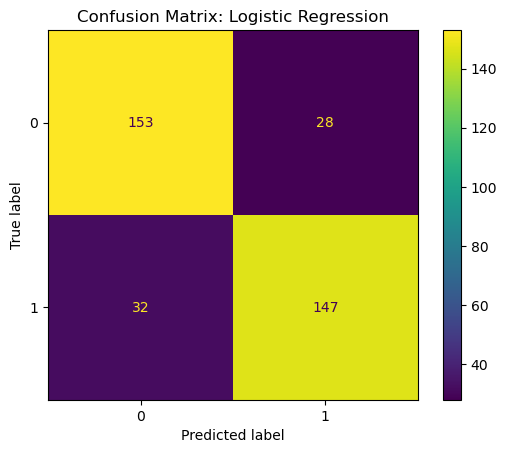

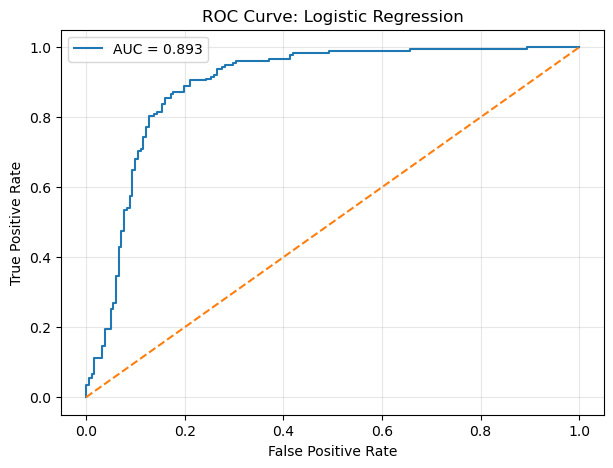

In [25]:
# Confusion matrix and ROC curve for logistic regression

logit_model.fit(X_train_cls, y_train_cls)
yhat_logit = logit_model.predict(X_test_cls)
proba_logit = logit_model.predict_proba(X_test_cls)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test_cls, yhat_logit)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_cls, proba_logit)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Decision Trees

A decision tree partitions the feature space into regions. For regression, each region predicts an average outcome. For classification, each region predicts a class probability.

At each split, the algorithm chooses a variable and cutoff that improve prediction.

Advantages:

- Easy to visualize.
- Handles nonlinearities and interactions.
- Requires little preprocessing.

Disadvantages:

- Can overfit badly.
- Small data changes can produce different trees.

In [27]:
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
models_reg.append(regression_report(tree_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg, 'Decision Tree Regressor'))

tree_cls = DecisionTreeClassifier(max_depth=4, random_state=42)
cls_rows.append(classification_report_row(tree_cls, X_train_cls, X_test_cls, y_train_cls, y_test_cls, 'Decision Tree Classifier'))

print('Regression comparison:')
print(pd.DataFrame(models_reg))

print('\nClassification comparison:')
print(pd.DataFrame(cls_rows))

Regression comparison:
                     Model  Train RMSE   Test RMSE  Train MAE    Test MAE  Train R2   Test R2
0                      OLS   25.467878   24.570488  20.446648   19.289531  0.982387  0.981275
1                    Ridge   25.467960   24.574705  20.446217   19.290256  0.982387  0.981268
2                    LASSO   25.549414   24.450878  20.476054   19.219567  0.982274  0.981457
3              Elastic Net   25.471613   24.588682  20.445109   19.300697  0.982382  0.981247
4  Decision Tree Regressor  117.546706  138.086445  92.722428  110.931887  0.624790  0.408574

Classification comparison:
                      Model  Accuracy  Precision    Recall        F1       AUC
0       Logistic Regression  0.833333   0.840000  0.821229  0.830508  0.892805
1  Decision Tree Classifier  0.858333   0.833333  0.893855  0.862534  0.889889


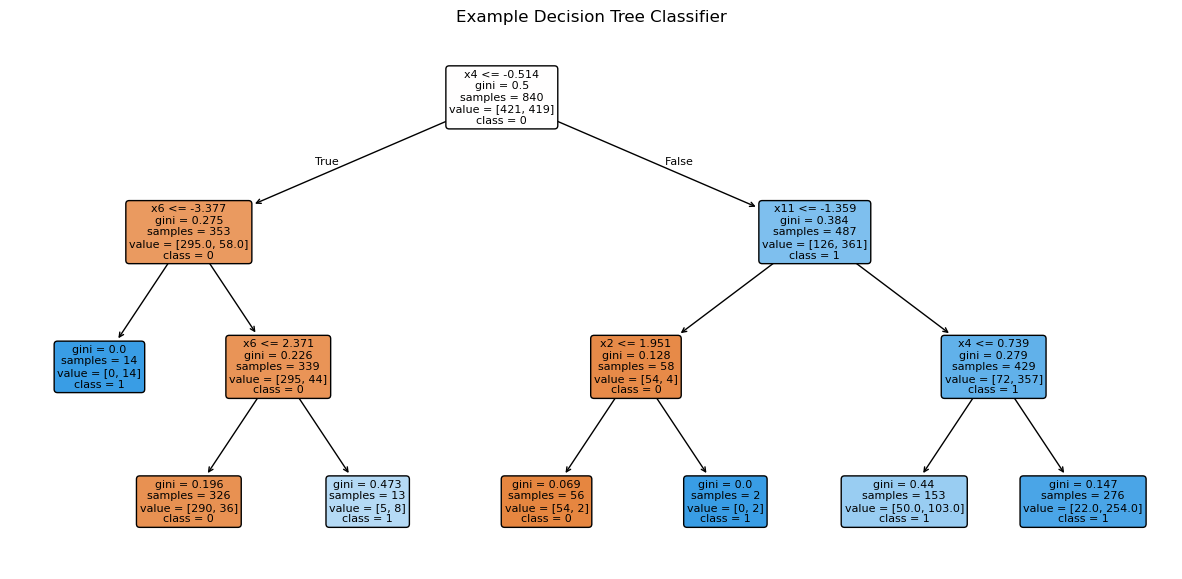

In [29]:
# Visualize a small classification tree

small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train_cls, y_train_cls)

plt.figure(figsize=(15, 7))
plot_tree(
    small_tree,
    filled=True,
    rounded=True,
    feature_names=[f'x{j}' for j in range(X_train_cls.shape[1])],
    class_names=['0', '1'],
    fontsize=8
)
plt.title('Example Decision Tree Classifier')
plt.show()

## 11. Support Vector Machines

A support vector machine classifies observations by finding a separating boundary with a large margin.

For a linear classifier, the decision boundary is

$$
w'x + b = 0.
$$

The closest observations are the **support vectors**. With kernels, SVMs can fit nonlinear boundaries. A common kernel is the radial basis function:

$$
K(x,z) = \exp(-\gamma \|x-z\|^2).
$$

SVMs can work well in high-dimensional spaces, but they require tuning and scaling.

In [31]:
svm_cls = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

cls_rows.append(classification_report_row(svm_cls, X_train_cls, X_test_cls, y_train_cls, y_test_cls, 'SVM Classifier'))

svm_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=10.0, gamma='scale'))
])

models_reg.append(regression_report(svm_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg, 'SVM Regressor'))

print(pd.DataFrame(cls_rows))
print(pd.DataFrame(models_reg))

                      Model  Accuracy  Precision    Recall        F1       AUC
0       Logistic Regression  0.833333   0.840000  0.821229  0.830508  0.892805
1  Decision Tree Classifier  0.858333   0.833333  0.893855  0.862534  0.889889
2            SVM Classifier  0.919444   0.903226  0.938547  0.920548  0.972190
                     Model  Train RMSE   Test RMSE  Train MAE    Test MAE  Train R2   Test R2
0                      OLS   25.467878   24.570488  20.446648   19.289531  0.982387  0.981275
1                    Ridge   25.467960   24.574705  20.446217   19.290256  0.982387  0.981268
2                    LASSO   25.549414   24.450878  20.476054   19.219567  0.982274  0.981457
3              Elastic Net   25.471613   24.588682  20.445109   19.300697  0.982382  0.981247
4  Decision Tree Regressor  117.546706  138.086445  92.722428  110.931887  0.624790  0.408574
5            SVM Regressor  107.674858  104.269987  80.053675   80.198657  0.685166  0.662777


## 12. $k$-Nearest Neighbors

The $k$-nearest neighbors method predicts using nearby observations.

For classification, KNN predicts the most common class among the $k$ nearest observations. For regression, it predicts their average outcome.

KNN is simple and flexible, but it can perform poorly in high dimensions because distance becomes less informative. Distance-based methods usually require feature scaling.

In [33]:
knn_cls = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15))
])

cls_rows.append(classification_report_row(knn_cls, X_train_cls, X_test_cls, y_train_cls, y_test_cls, 'KNN Classifier'))

pd.DataFrame(cls_rows)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.833333,0.840000,0.821229,0.830508,0.892805
1,Decision Tree Classifier,0.858333,0.833333,0.893855,0.862534,0.889889
2,SVM Classifier,0.919444,0.903226,0.938547,0.920548,0.972190
3,KNN Classifier,0.905556,0.879581,0.938547,0.908108,0.960354


## 13. Naive Bayes

Naive Bayes uses Bayes' rule:

$$
P(Y=k\mid X)
=
\frac{P(X\mid Y=k)P(Y=k)}{P(X)}.
$$

The “naive” assumption is conditional independence of features given the class:

$$
P(X_1,\ldots,X_p\mid Y=k)
=
\prod_{j=1}^p P(X_j\mid Y=k).
$$

This assumption is often false, but the classifier can still work surprisingly well.

In [35]:
nb_cls = GaussianNB()
cls_rows.append(classification_report_row(nb_cls, X_train_cls, X_test_cls, y_train_cls, y_test_cls, 'Naive Bayes'))

pd.DataFrame(cls_rows).sort_values('AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1,AUC
2,SVM Classifier,0.919444,0.903226,0.938547,0.920548,0.972190
3,KNN Classifier,0.905556,0.879581,0.938547,0.908108,0.960354
0,Logistic Regression,0.833333,0.840000,0.821229,0.830508,0.892805
1,Decision Tree Classifier,0.858333,0.833333,0.893855,0.862534,0.889889
4,Naive Bayes,0.802778,0.817647,0.776536,0.796562,0.862774


## 14. Comparing Classifiers

There is no universally best classifier. Different models impose different structures.

- Logistic regression: linear probability boundary in log-odds.
- Decision tree: nonlinear rules and interactions.
- SVM: maximum-margin classifier, often with nonlinear kernels.
- KNN: local similarity.
- Naive Bayes: probabilistic classification under conditional independence.

We should compare models using out-of-sample performance, not in-sample fit.

In [37]:
comparison_cls = pd.DataFrame(cls_rows).sort_values('AUC', ascending=False)
comparison_cls

,Model,Accuracy,Precision,Recall,F1,AUC
2,SVM Classifier,0.919444,0.903226,0.938547,0.920548,0.972190
3,KNN Classifier,0.905556,0.879581,0.938547,0.908108,0.960354
0,Logistic Regression,0.833333,0.840000,0.821229,0.830508,0.892805
1,Decision Tree Classifier,0.858333,0.833333,0.893855,0.862534,0.889889
4,Naive Bayes,0.802778,0.817647,0.776536,0.796562,0.862774


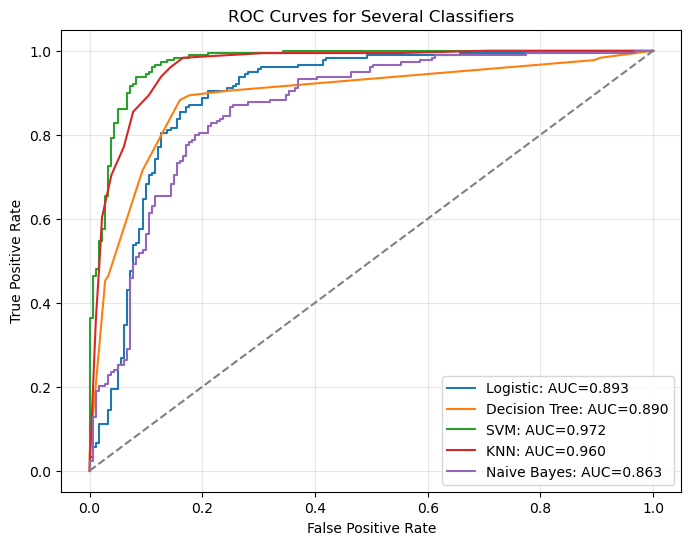

In [39]:
# Plot ROC curves for several classifiers

plt.figure(figsize=(8, 6))

models_for_roc = {
    'Logistic': logit_model,
    'Decision Tree': tree_cls,
    'SVM': svm_cls,
    'KNN': knn_cls,
    'Naive Bayes': nb_cls
}

for name, model in models_for_roc.items():
    model.fit(X_train_cls, y_train_cls)
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test_cls)[:, 1]
    else:
        scores = model.decision_function(X_test_cls)
    fpr, tpr, _ = roc_curve(y_test_cls, scores)
    plt.plot(fpr, tpr, label=f'{name}: AUC={auc(fpr, tpr):.3f}')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Several Classifiers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 15. Clustering with $k$-Means

Clustering is **unsupervised learning**. There is no outcome variable $Y$. The goal is to discover structure in the features.

$k$-means solves

$$
\min_{\{C_1,\ldots,C_k\}}
\sum_{j=1}^k
\sum_{i\in C_j}
\|x_i-\mu_j\|^2,
$$

where $\mu_j$ is the centroid of cluster $j$.

C:\Users\mlkelly0906\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


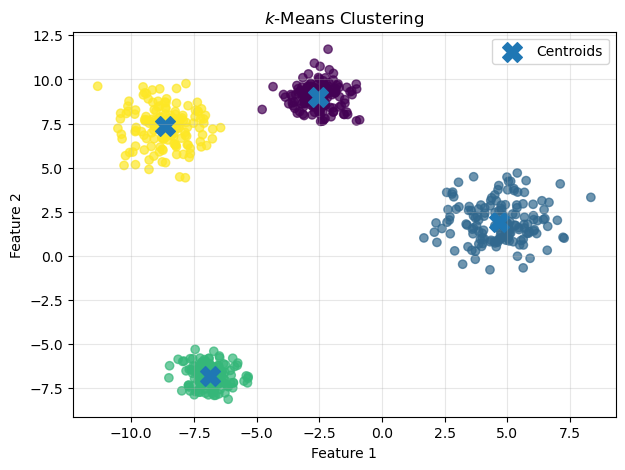

In [41]:
X_blobs, true_clusters = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=[0.7, 1.2, 0.6, 1.0],
    random_state=42
)

kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X_blobs)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=clusters, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, label='Centroids')
plt.title('$k$-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\mlkelly0906\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\mlkelly0906\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\mlkelly0906\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\mlkelly0906\AppData\Local\anaconda3\Lib\site-packages\sklearn\clust

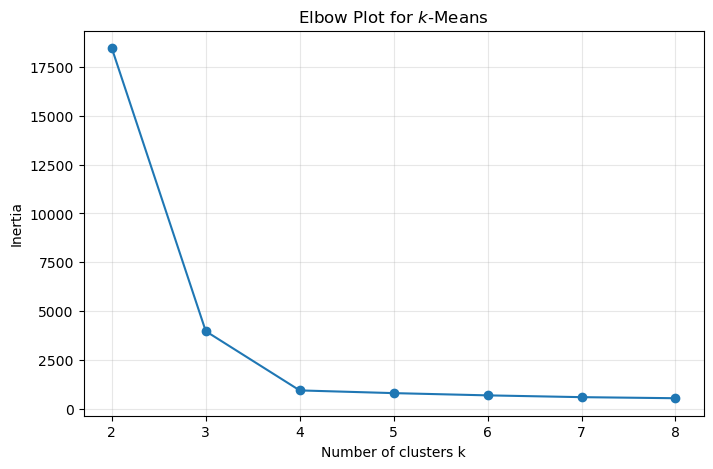

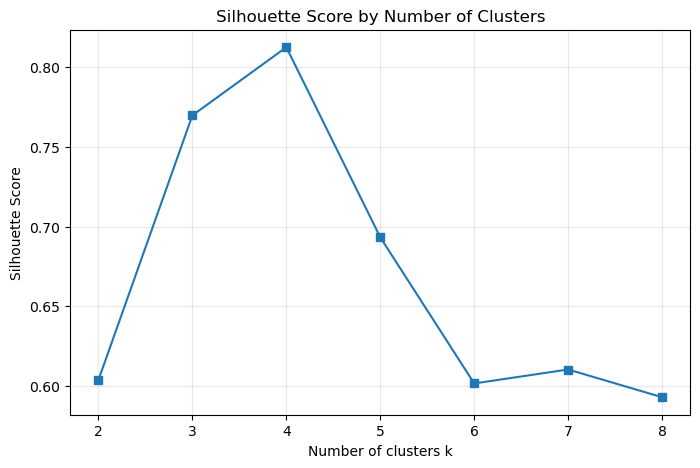

In [43]:
# Choosing k: inertia and silhouette score

ks = range(2, 9)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertias, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')
plt.title('Elbow Plot for $k$-Means')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(list(ks), silhouettes, marker='s')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

## 16. Principal Components Analysis

Principal components analysis, or PCA, is a dimensionality-reduction method.

Given many correlated variables, PCA constructs new variables called **principal components**. The first component explains the largest possible amount of variance. The second component explains the largest possible remaining variance subject to being orthogonal to the first, and so on.

If $X$ is standardized, PCA finds directions $v_j$ that solve

$$
\max_{v_j} Var(Xv_j)
$$

subject to

$$
v_j'v_j=1
$$

and orthogonality restrictions across components.

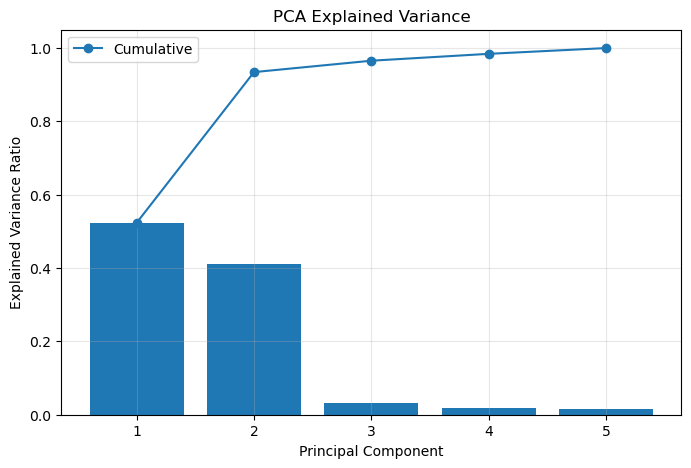

Explained variance ratios: [0.523 0.411 0.031 0.019 0.016]
Cumulative explained variance: [0.523 0.934 0.965 0.984 1.   ]


In [45]:
# PCA example with correlated data

np.random.seed(42)
n = 500
factor1 = np.random.normal(0, 1, n)
factor2 = np.random.normal(0, 1, n)

X_pca = np.column_stack([
    factor1 + 0.2 * np.random.normal(size=n),
    0.8 * factor1 + 0.3 * np.random.normal(size=n),
    factor2 + 0.2 * np.random.normal(size=n),
    -0.7 * factor2 + 0.3 * np.random.normal(size=n),
    0.5 * factor1 + 0.5 * factor2 + 0.3 * np.random.normal(size=n)
])

X_pca_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA()
scores = pca.fit_transform(X_pca_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.bar(np.arange(1, len(explained)+1), explained)
plt.plot(np.arange(1, len(explained)+1), np.cumsum(explained), marker='o', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Explained variance ratios:', np.round(explained, 3))
print('Cumulative explained variance:', np.round(np.cumsum(explained), 3))

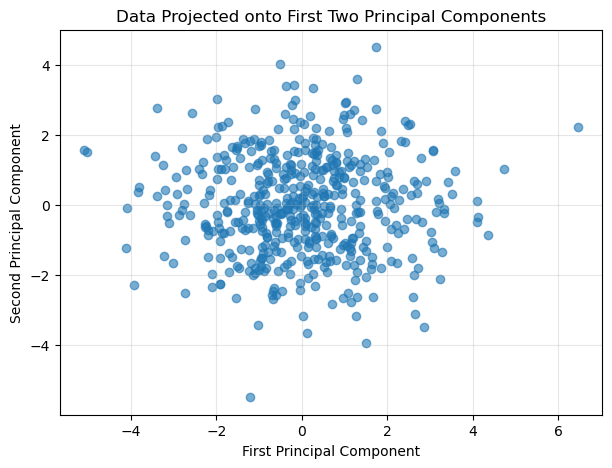

In [47]:
plt.figure(figsize=(7, 5))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.6)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Data Projected onto First Two Principal Components')
plt.grid(True, alpha=0.3)
plt.show()

## 17. Gradient Descent

Many machine-learning models are estimated by minimizing a loss function. For linear regression, the loss is often

$$
L(\beta)
=
\frac{1}{n}
\sum_{i=1}^n
(y_i-x_i'\beta)^2.
$$

Gradient descent updates the parameter vector in the direction that lowers the loss:

$$
\beta^{(m+1)}
=
\beta^{(m)}
-
\eta \nabla_\beta L(\beta^{(m)}),
$$

where $\eta$ is the **learning rate**.

For linear regression,

$$
\nabla_\beta L(\beta)
=
-\frac{2}{n}X'(Y-X\beta).
$$

Gradient descent estimates: [1.56298651 2.07060879]
OLS closed-form estimates: [1.56298652 2.07060883]


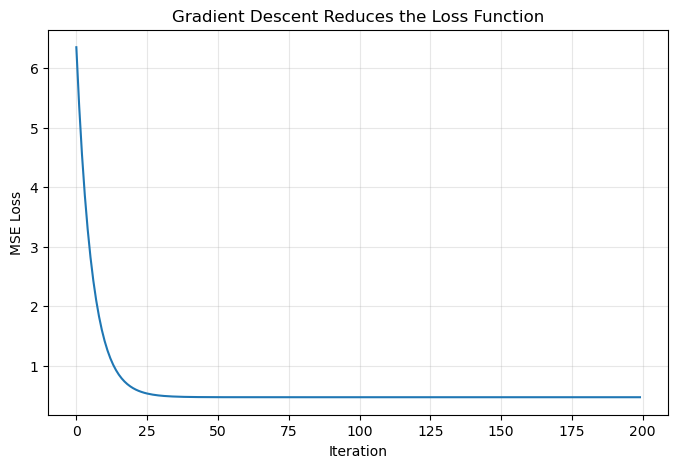

In [49]:
# Manual gradient descent for linear regression

np.random.seed(42)
n = 200
x = np.random.normal(size=n)
X_gd = np.column_stack([np.ones(n), x])
beta_true = np.array([1.5, 2.0])
y_gd = X_gd @ beta_true + np.random.normal(0, 0.7, n)

beta = np.array([0.0, 0.0])
eta = 0.05
iterations = 200
loss_history = []

for m in range(iterations):
    residuals = y_gd - X_gd @ beta
    loss = np.mean(residuals**2)
    grad = -(2 / n) * X_gd.T @ residuals
    beta = beta - eta * grad
    loss_history.append(loss)

print('Gradient descent estimates:', beta)

beta_ols = np.linalg.inv(X_gd.T @ X_gd) @ X_gd.T @ y_gd
print('OLS closed-form estimates:', beta_ols)

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Reduces the Loss Function')
plt.grid(True, alpha=0.3)
plt.show()

## 18. Neural Networks and Backpropagation

A neural network is a flexible function approximator built from layers.

A simple feedforward network with one hidden layer is

$$
\hat{y}
=
g_2
\left(
W_2
g_1(W_1x+b_1)
+
b_2
\right).
$$

Here:

- $W_1,W_2$ are weight matrices.
- $b_1,b_2$ are bias terms.
- $g_1,g_2$ are activation functions.
- The hidden layer constructs nonlinear transformations of the features.

Backpropagation computes gradients of the loss with respect to all weights using the chain rule:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z}
\frac{\partial z}{\partial w}.
$$

In [51]:
# Neural network classification on nonlinear data

X_moons, y_moons = make_moons(n_samples=800, noise=0.25, random_state=42)

X_train_moon, X_test_moon, y_train_moon, y_test_moon = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=42, stratify=y_moons
)

nn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(20, 20),
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=3000,
        random_state=42
    ))
])

logit_moon = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=5000))
])

tree_moon = DecisionTreeClassifier(max_depth=5, random_state=42)

moon_models = {
    'Logistic Regression': logit_moon,
    'Decision Tree': tree_moon,
    'Neural Network': nn_model
}

moon_results = []
for name, model in moon_models.items():
    model.fit(X_train_moon, y_train_moon)
    pred = model.predict(X_test_moon)
    moon_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_moon, pred),
        'F1': f1_score(y_test_moon, pred)
    })

pd.DataFrame(moon_results)

,Model,Accuracy,F1
0,Logistic Regression,0.891667,0.886957
1,Decision Tree,0.916667,0.911504
2,Neural Network,0.945833,0.944206


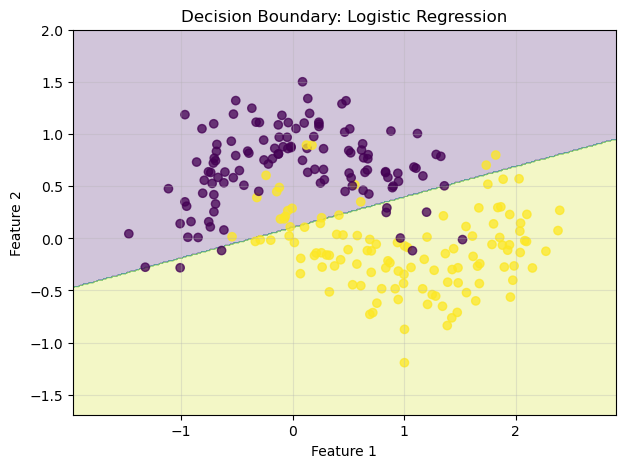

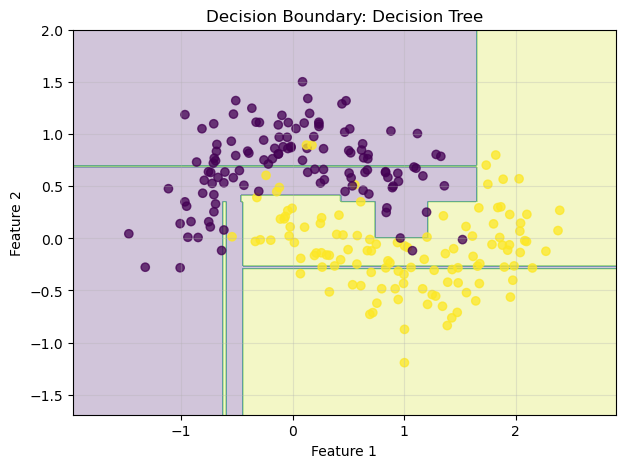

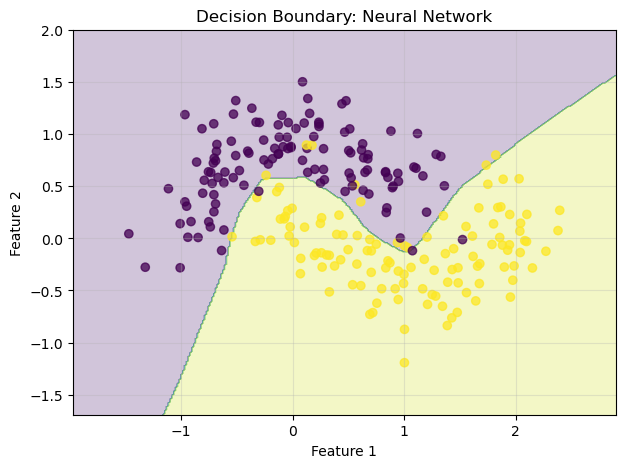

In [53]:
# Decision boundary helper

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.75)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, alpha=0.3)
    plt.show()

for name, model in moon_models.items():
    plot_decision_boundary(model, X_test_moon, y_test_moon, f'Decision Boundary: {name}')

## 19. A Practical Machine-Learning Workflow

A disciplined workflow looks like this:

1. Define the prediction target.
2. Choose the unit of observation.
3. Split the data into training and testing samples.
4. Build preprocessing steps using only training data.
5. Choose candidate models.
6. Use cross-validation to tune hyperparameters.
7. Evaluate final performance on the test sample once.
8. Report out-of-sample metrics.
9. Inspect errors, confusion matrices, ROC curves, or residuals.
10. Ask whether the model is stable, interpretable, and useful for the decision at hand.

Common errors include testing on the training data, leaking future information into the training sample, ignoring class imbalance, and confusing prediction with causation.

## 20. Summary

This lecture introduced modern machine-learning techniques for prediction and classification.

### Supervised learning

- Linear regression
- Ridge
- LASSO
- Elastic Net
- Logistic regression
- Decision trees
- Support vector machines
- $k$-nearest neighbors
- Naive Bayes
- Neural networks

### Unsupervised learning

- $k$-means clustering
- PCA

The essential machine-learning question is:

$$
\text{How well does the model predict new data?}
$$

The central practical tools are train/test splits, cross-validation, regularization, and out-of-sample metrics.